# chapter 3. 신경망
퍼셉트론으로 복잡한 함수도 표현할 수 있지만, 가중치를 설정하는 작업(원하는 겨로가를 출력하도록 가중치 값을 적절히 정하는 작업)은 여전히 사람이 수동으로 해야 함

신경망은 가중치 매개변수의 적절한 값을 데이터로부터 자동으로 학습하는 능력을 갖추고 있음\
이 것이 바로 이번 장에서 살펴볼 신경망의 중요한 특징\
이번 장에서는 신경망의 개요를 설명하고, 신경망이 입력 데이터가 무엇인지 식별하는 처리 과정을 자세히 알아봄

## 3.1 퍼셉트론에서 신경망으로
신경망은 퍼셉트론과 공통점이 많음\
이번 절에서는 퍼셉트론과 다른 점을 중심으로 신경망의 구조를 설명함\

### 3.1.1 신경망의 예
신경망을 그림으로 나타내면 아래 그림과 같음\
여기에서 가장 왼쪽 줄을 `입력층`, 맨 오른쪽 줄을 `출력층`, 중간 줄을 `은닉층`이라고 함\
은닉층의 뉴런은 입력층이나 출력층과 달리 사람 눈에는 보이지 않음\
우리는 입력층에서 출력층 방향으로 차례로 0층, 1층, 2층이라 함\
층 번호를 0부터 시작하는 이유는 파이썬 배열의 인덱스도 0부터 시작하여, 나중에 구현할 때 짝짓기 편하기 때문
<img src="image/img_3_1_neuralnetworkex.png" width="400" height="300">\
> 위 그림의 신경망은 모두 3층으로 구성되지만, 가중치를 갖는 층은 2개뿐이기에 '2층 신경망'이라고 함\
문헌에 따라서는 신경망을 구성하는 층수를 기준으로 '3층 신경망'이라고 하는 경우도 있음\
우리는 실제로 가중치를 갖는 층의 개수(입력층, 은닉층, 출력층의 합계에서 1을 뺀 값)를 기준으로 함

### 3.1.2 퍼셉트론 복습
<img src="image/img_2_1_perceptron.png" width="400" height="300">\
$$
y = \begin{cases} 0 & (b + w_1 x_1 + w_2 x_2 \leq 0) \\ 1 & (b + w_1 x_1 + w_2 x_2 > 0) \end{cases}
$$

여기서 b는 `편향`을 나타내는 매개변수로, 뉴런이 얼마나 쉽게 활성화되느냐를 제어함\
$w_1$과 $w_2$는 각 신호의 `가중치`를 나타내는 매개변수로, 각 신호의 영향력을 제어함\
위 그림에서 편향을 명시한다면\
<img src="image/img_3_2_perceptronwithbias.png" width="400" height="300">\
위 그림에서는 가중치가 b이고 입력이 1인 뉴런이 추가되었음\
이 퍼셉트론의 동작은 $x_1$, $x_2$, 1이라는 3개의 신호가 뉴런에 입력되어, 각 신호에 가중치를 곱한 후 다음 뉴런에 전달됨\
다음 뉴런에서는 이 신호들의 값을 더하여, 그 합이 0을 넘으면 1을 출력하고 그렇지 않으면 0을 출력함\
참고로 편향의 입력 신호는 항상 1이기 때문에 그림에서는 해당 뉴런을 회색으로 채워 다른 뉴런과 구별함\
위 수식을 간결한 형태로 다시 작성해보자\
이를 위해서 조건 분기의 동작(0을 넘으면 1을 출력하고 그렇지 않으면 0을 출력)을 하나의 함수로 나타냄\
이 함수를 $h(x)$라 하면 다음과 같이 표현할 수 있음
$$
y = h(b + w_1x_1 + w_2x_2)
\\[10pt]
h(x) = \begin{cases} 0 & (x \leq 0) \\ 1 & (x > 0) \end{cases}
$$

위 식은 입력 신호의 총합이 $h(x)$라는 함수를 거쳐 변환되어, 그 변환된 값이 $y$의 출력이 됨을 보여줌\
그리고 $h(x)$함수는 입력이 0을 넘으면 1을 돌려주고 그렇지 않으면 0을 돌려줌

### 3.1.3 활성화 함수의 등장
$h(x)$와 같이 입력 신호의 총합을 출력 신호로 변환하는 함수를 `활성화 함수(activation function)`라 함\
'활성화'라는 이름이 말해주듯 활성화 함수는 입력 신호의 총합이 활성화를 일으키는지를 정하는 역할을 함

위 식을 가중치가 곱해진 입력신호의 총합을 계산하고, 그 합을 활성화 함수에 입력해 결과를 내는 2단계 처리로 다시 써보면\
$$
a = b + w_1x_1 + w_2x_2
\\[10pt]
y = h(a)
$$

가중치가 달린 입력 신호와 편향의 총합을 계산하고, 이를 $a$라 함\
그리고 $a$를 함수 $h()$에 넣어 $y$를 출력하는 흐름

<img src="image/img_3_3_activationfn.png" width="400" height="300">

위 그림은 기존 뉴런 안에 활성화 함수의 처리 과정을 명시적으로 그렸음\
즉, 가중치 신호를 조합한 결과가 $a$라는 노드가 되고, 활성화 함수 $h()$를 통과하여 $y$라는 노드로 변환되는 과정이 분명하게 나타나 있음(`뉴런`과 `노드`는 같은 의미로 사용함)

> 단순 퍼셉트론은 단층 네트워크에서 계단 함수(임곗값을 경계로 출력이 바뀌는 함수)를 활성화 함수로 사용한 모델을 가리키고, 다층 퍼셉트론은 신경망(여러 층으로 구성되고 시그모이도 함수 등의 매끈한 활성화 함수를 사용하는 네트워크)을 가리킴

## 3.2 활성화 함수
활성화 함수는 임곗값을 경계로 출력이 바뀌는데, 이런 함수를 `계단 함수(step function)`라 함\
그래서 '퍼셉트론에서는 활성화 함수로 계단 함수를 이용한다'고 할 수 있음\
즉, 활성화 함수로 쓸 수 있는 여러 후보 중에서 퍼셉트론은 계단 함수를 채용하고 있음\
그렇다면 계단 함수 이외의 함수를 사용하면 어떻게 될까?\

### 3.2.1 시그모이드 함수
신경망에서 자주 이용하는 활성화 함수인 `시그모이드 함수(sigmoid function)`의 식은 다음과 같음
$$
h(x) = \frac{1}{1 + e^{-x}}
$$

시그모이드 함수는 얼핏 복잡해 보이지만 이 역시 단순한 '함수'이며, 입력을 주면 출력을 돌려주는 변환기임\
예를 들어 시그모이드 함수에 1.0과 2.0을 입력하면 $h(1.0)=0.731...$, $h(2.0)=0.880...$처럼 특정 값을 출력함\
신경망에서는 활성화 함수로 시그모이드 함수를 이용하여 신호를 변환하고, 그 변환된 신호를 다음 뉴런에 전달함\
사실 퍼셉트론과 신경망의 주된 차이는 이 활성화 함수뿐임\
그 외에 뉴런이 여러 층으로 이어지는 구조와 신호를 전달하는 방법은 기본적으로 퍼셉트론과 같음

### 3.2.2 계단 함수 구현하기
계단 함수는 입력이 0을 넘으면 1을 출력하고, 그 외에는 0을 출력하는 함수\
다음은 이러한 계단 함수를 단순하게 구현한 코드

In [6]:
def step_function(x):
    if x > 0:
        return 1
    else:
        return 0

이 구현은 단순하고 쉽지만, 인수 x는 실수(부동소수점)만 받아들임\
즉, step_function(3.0)은 되지만 넘파이 배열을 인수로 넣을 수는 없음\
예를 들어 step_function(np.array([1.0,2.0]))은 안됨\
앞으로를 위해 넘파이 배열도 지원하도록 수정하고 싶다면?

In [7]:
def step_function(x):
    y = x > 0
    return y.astype(int)

겨우 두 줄이지만 넘파이의 편리한 트릭을 사용한 덕분임\
다음 예시에서는 x라는 넘파이 배열을 준비하고, 그 넘파이 배열에 부등호 연산을 수행함

In [8]:
import numpy as np
x = np.array([-1.0, 1.0, 2.0])
x

array([-1.,  1.,  2.])

In [9]:
y = x > 0
y

array([False,  True,  True])

넘파이 배열에 부등호 연산을 수행하면 배열의 원소 각각에 부등호 연산을 수행한 bool 배열이 생성됨\
이 예시에서는 배열 x의 원소 각각이 0보다 크면 True로, 0 이하면 False로 변환한 새로운 배열 y가 생성됨

이 y는 bool 배열임\
그런데 우리가 원하는 계단 함수는 0이나 1의 'int형'을 출력하는 함수이기에 배열 y의 원소를 bool에서 int형으로 바꿔줌

In [10]:
y = y.astype(int)
y

array([0, 1, 1])

이처럼 넘파이 배열의 자료형을 변환할 때는 astype() 메서드를 이용함\
원하는 자료형을 인수로 지정하면 됨\
파이썬에서는 bool을 int로 변환하면 True는 1로, False는 0으로 변환됨

### 3.2.3 계단 함수의 그래프
정의한 계단 함수를 그래프로 그려볼 것임\
이를 위해 맷플롯립 라이브러리를 사용함

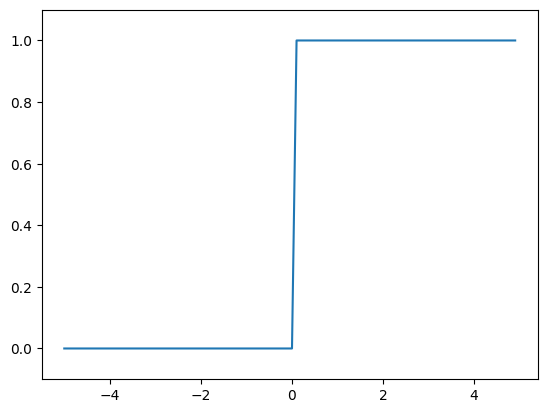

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def step_function(x):
    return np.array(x>0, dtype=int)

x = np.arange(-5.0, 5.0, 0.1) # -5.0에서 5.0전까지 0.1 간격의 넘파이 배열을 생성함
y = step_function(x)

plt.plot(x,y)
plt.ylim(-0.1, 1.1) # y축 범위 지정
plt.show()

위처럼 계단 함수는 0을 경계로 출력이 0에서 1(또는 1에서 0)로 바뀜\
값이 바뀌는 형태가 계단처럼 생겼기 때문에 계단 함수라고 함

### 3.2.4 시그모이드 함수 구현하기
시그모이드 함수는 파이썬으로 다음과 같이 작성할 수 있음

In [12]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

여기서 np.exp(-x)는 exp(-x)수식에 해당함\
인수 x가 넘파이 배열이어도 올바른 결과가 나옴

In [13]:
x = np.array([-1.0, 1.0, 2.0])
sigmoid(x)

array([0.26894142, 0.73105858, 0.88079708])

이 함수가 넘파이 배열을 처리할 수 있는 이유는 넘파이의 브로드캐스트 덕분임
* 브로드캐스트란 넘파이 배열과 스칼라값의 연산을 넘파이 배열의 원소 각각과 스칼라값의 연산으로 바꿔 수행하는 기능

이제 시그모이드 함수를 그래프로 그려봄

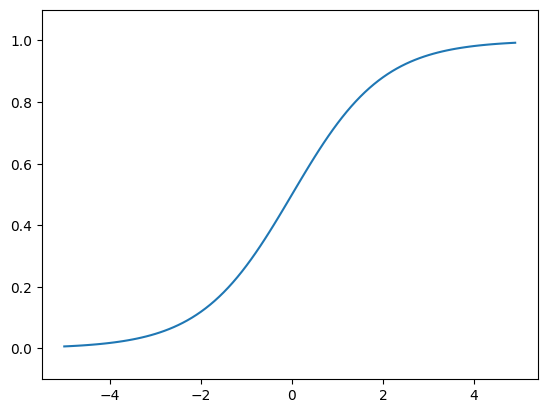

In [14]:
x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x) # sigmoid 함수로 변경

plt.plot(x,y)
plt.ylim(-0.1, 1.1)
plt.show()

### 3.2.5 시그모이드 함수와 계단 함수 비교

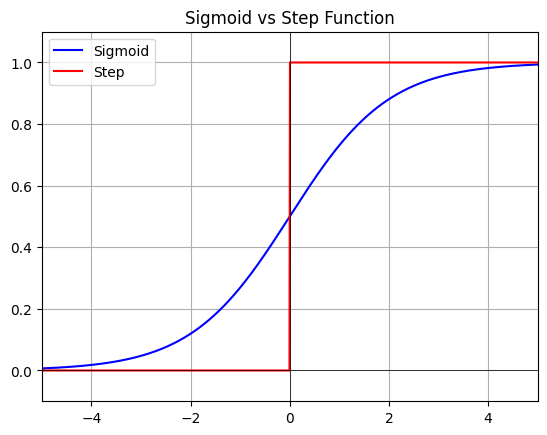

In [15]:
x = np.linspace(-5, 5, 1000)
plt.plot(x, sigmoid(x), color='blue', label='Sigmoid')
plt.plot(x, step_function(x), color='red', label='Step')
plt.xlim(-5, 5)
plt.ylim(-0.1, 1.1)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.grid(True)
plt.title('Sigmoid vs Step Function')
plt.show()
plt.show()


시그모이드 함수와 계단 함수를 비교해봄\
가장 먼저 느껴지는 점은 '매끄러움'의 차이\
시그모이드 함수는 부드러운 곡선이며 입력에 따라 출력이 연속적으로 변화함\
계단 함수는 0을 경계로 출력이 갑자기 바뀌어버림\
시그모이드 함수의 이 매끈함이 신경망 학습에서 중요한 역할을 하게 됨

매끈함과 관련되는데 계단 함수가 0과 1중 하나의 값만 돌려주는 반면 시그모이드 함수는 실수(0.731..., 0.880... 등)를 돌려준다는 점도 다름\
다시 말해 퍼셉트론에서는 뉴런 사이에 0 혹은 1이 흘렀다면 신경망에서는 연속적인 실수가 흐름

두 함수는 매끄러움이라는 점에서는 다르지만 큰 관점에서 보면 같은 모양을 하고 있음\
둘 다 입력이 작을 때의 출력은 0에 가깝고(혹은 0이고), 입력이 커지면 출력이 1에 가까워지는(혹은 1이 되는) 구조\
즉, 계단 함수와 시그모이드 함수는 입력이 중요하면 큰 값을 출력하고 입력이 중요하지 않으면 작은 값을 출력함\
입력이 아무리 작거나 커도 출력은 0에서 1 사이라는 점도 둘의 공통점

### 3.2.6 비선형 함수
계단 함수와 시그모이드 함수는 `비선형 함수`\
신경망에서는 활성화 함수로 비선형 함수를 사용해야 함\
선형 함수를 이용하면 신경망의 층을 깊게 하는 의미가 없어지기 때문\
선형 함수의 문제는 층을 아무리 깊게 해도 '은닉층이 없는 네트워크'로도 똑같은 기능을 할 수 있음\
따라서 선형 함수를 이용해서는 여러 층으로 구성하는 이점을 살릴 수 없음\
그래서 층을 쌓는 혜택을 얻고 싶다면 활성화 함수로는 반드시 비선형 함수를 사용해야 함

### 3.2.7 ReLU 함수


지금까지 활성화 함수로 계단 함수와 시그모이드 함수를 소개하였음\
시그모이드 함수는 신경망 분야에서 오래전부터 이용해왔으나, 최근에는 `ReLU(Rectified Linear Unit)` 함수를 주로 이용함\
ReLU는 입력이 0을 넘으면 그 입력을 그대로 출력하고, 0이하면 0을 출력하는 함수

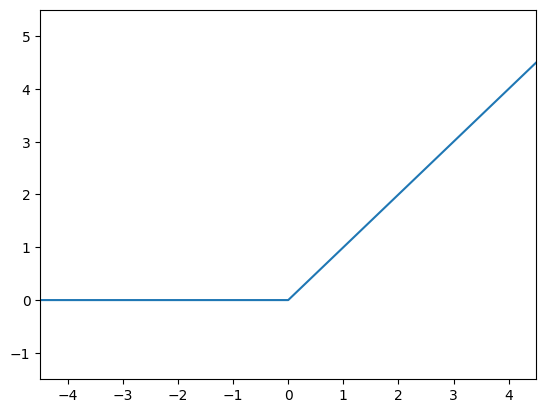

In [16]:
def relu(x):
    return np.maximum(0,x)

x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)

plt.plot(x,y)
plt.xlim(-4.5,4.5)
plt.ylim(-1.5,5.5)
plt.show()

$$
h(x) = \begin{cases} 0 & (x \leq 0) \\ x & (x > 0) \end{cases}
$$

## 3.3 다차원 배열의 계산
넘파이의 다차원 배열을 사용한 계산법을 숙달하면 신경망을 효율적으로 구현할 수 있음

### 3.3.1 다차원 배열
다차원 배열도 그 기본은 '숫자의 집합'임\
숫자가 한 줄로 늘어선 것이나 직사각형으로 늘어놓은 것, 3차원으로 늘어놓은 것이나 N차원으로 나열하는 것을 통틀어 다차원 배열이라고 함\
먼저 1차원 배열을 작성하면 다음과 같음

In [17]:
import numpy as np
A = np.array([1,2,3,4])
print(A)

[1 2 3 4]


In [18]:
np.ndim(A)

1

In [19]:
A.shape

(4,)

In [20]:
A.shape[0]

4

위와 같이 배열의 차원 수는 np.ndim()함수로 확인할 수 있음\
또 배열의 형상은 인스턴스 변수인 shape로 알 수 있음\
이 예에서 A는 1차원 배열이고 원소 4개로 구성되어 있음을 알 수 있고 A.shape이 튜플을 반환함\
이는 1차원 배열이라도 다차원 배열일 때와 통일된 형태로 결과를 반환하기 위함임\
이어서 2차원 배열을 작성하면 다음과 같음

In [21]:
B = np.array([[1,2],
              [3,4],
              [5,6]])
print(B)

[[1 2]
 [3 4]
 [5 6]]


In [22]:
np.ndim(B)

2

In [23]:
B.shape

(3, 2)

여기에서는 '3x2 배열'인 B를 작성함\
3x2배열은 처음 차원에는 원소가 3개, 다음 차원에는 원소가 2개 있다는 의미\
이 때 처음 차원은 0번째 차원, 다음 차원은 1번째 차원에 대응함(파이썬의 인덱스는 0부터 시작)\
2차원 배열은 특히 `행렬(matrix)`이라고 부르고 가로 방향을 `행`, 세로 방향을 `열`이라고 함

### 3.3.2 행렬의 곱

In [24]:
A = np.array([[1,2],
              [3,4]])

B = np.array([[5,6],
              [7,8]])

In [25]:
A.shape

(2, 2)

In [26]:
B.shape

(2, 2)

In [27]:
np.dot(A,B)

array([[19, 22],
       [43, 50]])

### 3.3.3 신경망에서의 행렬 곱
넘파이 행렬을 써서 신경망을 구현해볼 것임\
편향과 활성화 함수를 생략하고 가중치만 갖는 간단한 신경망을 가정해봄

In [28]:
X = np.array([1,2])
X.shape

(2,)

In [29]:
W = np.array([[1,3,5],
             [2,4,6]])
print(W)

[[1 3 5]
 [2 4 6]]


In [30]:
W.shape

(2, 3)

In [31]:
Y = np.dot(X,W)
print(Y)

[ 5 11 17]


다차원 배열의 스칼라곱을 구해주는 np.dot함수를 사용하면 이처럼 단번에 결과 Y를 계산할 수 있음\
Y의 원소가 100개든 1000개든 한 번의 연산으로 계산할 수 있음\
만약 np.dot을 사용하지 않으면 Y의 원소를 하나씩 따져봐야 함(또는 for문을 사용해서 계산)\
그렇기에 행렬의 곱으로 한번에 계산해주는 기능은 신경망을 구현할 때 매우 중요함

## 3.4 3층 신경망 구현하기
이번에는 3층 신경망에서 수행되는, 입력부터 출력까지의 처리(순방향 처리)를 구현할 것임\
이를 위해 앞에서 설명한 넘파이의 다차원 배열을 사용함

### 3.4.1 표기법 설명
이번 절에서는 신경망에서의 처리를 설명하며 $w_{12}^{(1)}$과 $a_{1}^{(1)}$과 같은 표기법이 존재함\
$w_{12}^{(1)}$의 아래 첨자는 앞층의 2번째 뉴런에서 다음층의 1번째 뉴런을 뜻함\
$w_{12}^{(1)}$의 위 첨자는 1층의 가중치를 뜻함\
$w_{12}^{(1)}$는 앞 층의 2번째 뉴런에서 다음층의 1번째 뉴런($a_{1}^{(1)}$)으로 향할 때의 가중치라는 뜻

### 3.4.2 각 층의 신호 전달 구현하기
입력층에서 '1층의 1번째 뉴런'으로 가는 신호를 살펴볼 것임\
<img src="image/img_3_4_inputtofirstlayer.png" width="400" height="300">\
지금까지 확인한 내용을 반영하여 $a_{1}^{(1)}$을 수식으로 나타내보면 다음과 같음
$$
a_{1}^{(1)} = w_{11}^{(1)}x_1 + w_{12}^{(1)}x_2 + b_{1}^{(1)}
$$

여기에서 행렬의 곱을 이용하면 1층의 '가중치 부분'을 다음 식처럼 간소화할 수 있음
$$
A^{(1)} = XW^{(1)} + B^{(1)}
$$

이때 각 행렬은 다음과 같음
$$
A^{(1)} = (a_{1}^{(1)}\quad a_{2}^{(1)}\quad a_{3}^{(1)})
\\[10pt]
X = (x_1\quad x_2)
\\[10pt]
B^{(1)} = (b_{1}^{(1)}\quad b_{2}^{(1)}\quad b_{3}^{(1)})
\\[10pt]
W^(1) = 
\begin{pmatrix}
w_{11}^{(1)} & w_{21}^{(1)} & w_{31}^{(1)}
\\
w_{12}^{(1)} & w_{22}^{(1)} & w_{32}^{(1)}
\end{pmatrix}
$$

넘파이의 다차원 배열을 사용해서 위 식을 구현해보면 다음과 같음

In [32]:
X = np.array([1.0, 0.5])
W1 = np.array([[0.1, 0.3, 0.5],
               [0.2, 0.4, 0.6]])
B1 = np.array([0.1, 0.2, 0.3])

print(W1.shape)
print(X.shape)
print(B1.shape)

A1 = np.dot(X, W1) + B1

(2, 3)
(2,)
(3,)


W1은 2x3 행렬, X는 원소가 2개인 1차원 배열임\
여기에서도 W1과 X의 대응하는 차원의 원소 수가 일치함

이어서 1층의 활성화 함수에서의 처리를 살펴봄\
은닉층에서의 가중치 합(가중 신호와 편향의 총합)을 $a$로 표기하고 활성화 함수 $h()$로 변환된 신호를 $z$로 표기\
활성화 함수로 시그모이드 함수를 사용하며, 이를 파이썬으로 구현하면 다음과 같음

In [33]:
Z1 = sigmoid(A1)
print(A1)

[0.3 0.7 1.1]


In [34]:
print(Z1)

[0.57444252 0.66818777 0.75026011]


시그모이드 함수는 앞서 정의한 함수로, 넘파이 배열을 받아 같은 수의 원소로 구성된 넘파이 배열을 반환함

이어서 1층에서 2층으로 가는 과정과 구현을 살펴보면 다음과 같음

In [35]:
W2 = np.array([[0.1, 0.4],
               [0.2, 0.5],
               [0.3, 0.6]])

B2 = np.array([0.1, 0.2])

print(Z1.shape)
print(W2.shape)
print(B2.shape)

A2 = np.dot(Z1, W2) + B2
Z2 = sigmoid(A2)

(3,)
(3, 2)
(2,)


이 구현은 1층의 출력 Z1이 2층의 입력이 된다는 점을 제외하면 조금 전의 구현과 같음\
이처럼 넘파이 배열을 사용하면서 층 사이의 신호 전달을 쉽게 구현할 수 있음

마지막으로 2층에서 출력층으로의 신호 전달임\
출력층의 구현도 그동안의 구현과 거의 같지만 활성화 함수만 지금까지의 은닉층과 다름

In [36]:
def identity_function(x):
    return x

W3 = np.array([[0.1, 0.3],
               [0.2, 0.4]])
B3 = np.array([0.1, 0.2])

A3 = np.dot(Z2, W3) + B3
Y = identity_function(A3)

여기에서는 항등 함수인 identity_function()을 정의하고, 이를 출력층의 활성화 함수로 이용하였음\
항등 함수는 그대로 출력하는 함수이기에 굳의 정의할 필요는 없지만 그동안의 흐름과 통일하기 위해 구현함\
출력층의 활성화 함수를 $\sigma()$ 로 표시하여 은닉층의 활성화 함수 $h()$와는 다름을 명시함

> 출력층의 활성화 함수는 풀고자 하는 문제의 성질에 맞게 정함\
예를 들어 회귀에는 항등 함수를, 2클래스 분류에는 시그모이드 함수를, 다중 클래스 분류에는 소프트맥스 함수를 사용하는 것이 일반적임

### 3.4.3 구현 정리
지금 까지의 구현을 정리하여 신경망을 구성하는 코드를 작성

In [37]:
def init_network():
    network = {}
    network['W1'] = np.array([[0.1, 0.3, 0.5],
                              [0.2, 0.4, 0.6]])
    network['b1'] = np.array([0.1, 0.2, 0.3])
    network['W2'] = np.array([[0.1, 0.4],
                              [0.2, 0.5],
                              [0.3, 0.6]])
    network['b2'] = np.array([0.1, 0.2])
    network['W3'] = np.array([[0.1, 0.3],
                              [0.2, 0.4]])
    network['b3'] = np.array([0.1, 0.2])
    
    return network

def forward(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']
    
    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = identity_function(a3)
    
    return y

network = init_network()
x = np.array([1.0, 0.5])
y = forward(network, x)
print(y)

[0.31682708 0.69627909]


init_network()와 forward()라는 함수를 정의하였음\
init_network()함수는 가중치와 편향을 초기화하고 이들을 딕셔너리 변수인 network에 저장함\
이 딕셔너리 변수 network에는 각 층에 필요한 매개변수(가중치와 편향)를 저장함\
forward()함수는 입력 신호를 출력으로 변환하는 처리 과정을 모두 구현하고 있음

함수 이름을 forward라 한 이유는 신호가 순방향(입력에서 출력 방향)으로 전달됨(순전파)을 알리기 위함\
앞으로 신경망 학습을 다룰 때 역방향(backward, 출력에서 입력 방향)처리에 대해서도 살펴볼 것임

## 3.5 출력층 설계하기
신경망은 분류와 회귀 모두에 이용할 수 있음\
다만 둘 중 어떤 문제냐에 따라 출력층에서 사용하는 활성화 함수가 달라짐\
일반적으로 회귀에는 항등 함수를, 분류에는 소프트맥스 함수를 사용함

> 머신러닝 문제는 분류와 회귀로 나뉨\
분류는 데이터가 어느 클래스에 속하느냐는 문제로 사진 속 인물의 성별을 분류하는 문제가 여기에 속함\
회귀는 입력 데이터에서 연속적인 수치를 예측하는 문제로 사진 속 인물의 몸무게를 예측하는 문제가 여기에 속함

### 3.5.1 항등 함수와 소프트맥스 함수 구현하기
`항등 함수(identity function)`는 입력을 그대로 출력함\
입력과 출력이 항상 같다는 뜻의 항등임\
그래서 출력층에서 항등 함수를 사용하면 입력 신호가 그대로 출력 신호가 됨

분류에서 사용하는 소프트 맥스 함수의 식은 다음과 같음
$$
y_k = \frac{e^{a_k}}{\sum_{i=1}^{n} e^{a_i}}
$$

$n$은 출력층의 뉴런 수, $y_k$는 그중 $k$번째 출력임을 뜻함\
소프트맥스 함수의 분자는 입력 신호 $a_k$의 지수 함수, 분모는 모든 입력 신호의 지수 함수의 합으로 구성됨

소프트맥스 함수를 구현해보면 다음과 같음

In [38]:
a = np.array([0.3, 2.9, 4.0])

exp_a = np.exp(a)
print(exp_a)

[ 1.34985881 18.17414537 54.59815003]


In [39]:
sum_exp_a = np.sum(exp_a)
print(sum_exp_a)

74.1221542101633


In [40]:
y = exp_a / sum_exp_a
print(y)

[0.01821127 0.24519181 0.73659691]


위의 논리 흐름을 파이썬 함수로 정의하여, 필요할 때 사용할 수 있도록 작성함

In [41]:
def softmax(a):
    exp_a = np.exp(a)
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a
    
    return y

### 3.5.2 소프트맥스 함수 구현 시 주의점
앞 절에서 구현한 softmax()함수의 코드는 식을 제대로 표현하고 있지만, 컴퓨터로 계산할 때는 결함이 존재함\
그것은 바로 오버플로 문제임\
소프트 맥스 함수는 지수 함수를 사용하는데, 지수 함수란 것이 아주 큰 값을 쉽게 내뱉음\
가령 $e^{10}$은 20,000이 넘고, $e^{100}$은 0이 40개가 넘는 큰 값이, $e^{1000}$은 무한대를 뜻하는 inf가 되어 돌아옴\
그리고 이런 큰 값끼리 나눗셈을 하면 결과 수치가 '불안정'해짐

> 컴퓨터는 수(number)를 4바이트나 8바이트와 같이 크기가 유한한 데이터로 다룸\
다시 말해 표현할 수 있는 수의 범위가 한정되어 너무 큰 값은 표현할 수 없다는 문제가 발생함\
이 현상을 오버플로(overflow)라 하며, 컴퓨터로 수치를 계산할 때 주의해야 함


이 문제를 해결하도록 소프트맥스 함수 구현을 개선하면 다음과 같음
$$
y_k = \frac{e^{a_k}}{\sum_{i=1}^{n} e^{a_i}} \quad
    = \frac{Ce^{a_k}}{C\sum_{i=1}^{n} e^{a_i}}\quad
    = \frac{e^{a_k + logC}}{\sum_{i=1}^{n} e^{a_i + logC}}\quad
    = \frac{e^{a_k + C'}}{\sum_{i=1}^{n} e^{a_i + C'}}
$$

식의 전개 과정을 살펴보자\
첫 번째 변형에서는 C라는 임의의 정수를 분자와 분모 양쪽에 곱하였음\
그 다음으로 C를 지수 함수 안으로 옮겨 $logC$로 만들었음\
마지막으로 $logC$를 $C'$라는 새로운 기호로 변경함

위의 식이 의미하는 바는 소프트맥스의 지수 함수를 계산할 때 어떤 정수를 더해도(혹은 빼도) 결과는 바뀌지 않는다는 것\
여기서 $C'$에 어떤 값을 대입해도 상관없지만, 오버플로를 막을 목적으로는 입력 신호 중 최댓값을 이용하는 것이 일반적\
구체적인 예시를 하나 살펴보자

In [42]:
a = np.array([1010, 1000, 900])
np.exp(a) / np.sum(np.exp(a))

/var/folders/gr/1r0zsf75231d5gylt0gl0wsm0000gn/T/ipykernel_1961/2307151752.py:2: RuntimeWarning: overflow encountered in exp
  np.exp(a) / np.sum(np.exp(a))
/var/folders/gr/1r0zsf75231d5gylt0gl0wsm0000gn/T/ipykernel_1961/2307151752.py:2: RuntimeWarning: invalid value encountered in divide
  np.exp(a) / np.sum(np.exp(a))


/var/folders/gr/1r0zsf75231d5gylt0gl0wsm0000gn/T/ipykernel_1961/2307151752.py:2: RuntimeWarning: overflow encountered in exp
  np.exp(a) / np.sum(np.exp(a))
/var/folders/gr/1r0zsf75231d5gylt0gl0wsm0000gn/T/ipykernel_1961/2307151752.py:2: RuntimeWarning: invalid value encountered in divide
  np.exp(a) / np.sum(np.exp(a))


array([nan, nan, nan])

In [43]:
c = np.max(a)
a - c

array([   0,  -10, -110])

In [44]:
np.exp(a - c)/np.sum(np.exp(a - c))

array([9.99954602e-01, 4.53978687e-05, 1.68883521e-48])

위 예시에서 보는 것처럼 아무런 조치 없이 그냥 계산하면 nan이 출력됨(not a number)\
하지만 입력 신호 중 최댓값(이 예시에서는 c)을 빼주면 올바르게 계산할 수 있음\
이를 바탕으로 소프트맥스 함수를 다시 구현하면 다음과 같음

In [45]:
def softmax(a):
    c = np.max(a)
    exp_a = np.exp(a - c)
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a
    
    return y

### 3.5.3 소프트맥스 함수의 특징
softmax()함수를 사용하면 신경망의 출력은 다음과 같이 계산할 수 있음

In [46]:
a = np.array([0.3, 2.9, 4.0])
y = softmax(a)
print(y)

[0.01821127 0.24519181 0.73659691]


In [47]:
print(np.sum(y))

1.0


소프트맥스 함수의 출력은 0에서 1.0 사이의 실수임\
또 소프트맥스 함수 출력의 총합은 1임\
출력 총합이 1이 된다는 점은 소프트맥스 함수의 중요한 성질임\
이 성질 덕분에 소프트맥스 함수의 출력을 '확률'로 해석할 수 있음

가령 예시에서 y[0]의 확률은 0.018(1.8%), y[1]의 확률은 0.245(24.5%), y[2]의 확률은 0.737(73.7%)로 해석가능\
그리고 이 결과 확률들로부터 '2번째 원소의 확률이 가장 높으니, 답은 2번째 클래스다'라고 할 수 있음\
혹은 '74%의 확률로 2번째 클래스, 25%의 확률로 1번째 클래스, 1%의 확률로 0번째 클래스다'와 같이 확률적인 결론도 낼 수 있음\
즉 소프트맥스 함수를 이용함으로써 문제를 확률적(통계적)으로 대응할 수 있게 됨

여기서 주의할 점은 소프트맥스 함수를 적용해도 각 원소의 대소 관계는 변하지 않는다는 사실임\
이는 지수함수 $y = e^x$가 단조 증가 함수이기 때문임\

신경망을 이용한 분류에서는 일반적으로 가장 큰 출력을 내는 뉴런에 해당하는 클래스로만 인식함\
그리고 소프트맥스 함수를 적용해도 출력이 가장 큰 뉴런의 위치는 달라지지 않음\
결과적으로 신경망으로 분류할 때는 출력층의 소프트맥스 함수를 생략해도 됨\
현업에서도 지수 함수 계산에 드는 자원 낭비를 줄이고자 출력층의 소프트맥스 함수는 생략하는 것이 일반적임

> 머신러닝의 문제 풀이는 `학습`과 `추론`의 두 단계를 거쳐 이루어짐\
학습 단계에서 모델을 학습하고, 추론 단계에서 앞서 학습한 모델로 미지의 데이터에 대해서 추론(분류)을 수행함\
추론 단계에서는 일반적으로 출력층의 소프트맥스 함수를 생략함\
한편 신경망을 학습시킬 때는 출력층에서 소프트맥스 함수를 사용함

### 3.5.4 출력층의 뉴런 수 정하기
출력층의 뉴런 수는 풀려는 문제에 맞게 적절히 정해야 함\
분류에서는 분류하고 싶은 클래스 수로 설정하는 것이 일반적임\
예를 들어 입력 이미지 숫자 0부터 0 중 하나로 분류하는 문제라면 출력층의 뉴런을 10개로 설정함\
출력층 뉴런은 위에서부터 차례로 숫자 0, 1, ..., 9에 대응하며, 뉴런의 확률이 해당 뉴런의 출력 값의 크기를 의미\
가장 높은 값이 $y_2$뉴런이라면 신경망이 선택한 클래스는 $y_2$, 즉 입력 이미지를 숫자'2'로 판단했음을 의미함

## 3.6 손글씨 숫자 인식
신경망의 구조를 배웠으니 손글씨 숫자 분류에 적용해봄\
이번 절에서는 이미 학습된 매개변수를 사용하여 학습 과정은 생략하고 추론 과정만 구현할 것임\
이 추론 과정을 신경망의 `순전파(forward propagtion)`라고도 함

> 머신러닝과 마찬가지로 신경망도 두 단계를 거쳐 문제를 해결함\
먼저 훈련 데이터(학습 데이터)를 사용해 가중치 매개변수를 학습하고, 추론 단계에서는 앞서 학습한 매개변수를 사용하여 입력 데이터를 분류함

### 3.6.1 MNIST 데이터셋
MNIST 데이터셋은 손글씨 숫자 이미지 집합으로 0부터 9까지의 숫자 이미지로 구성됨\
훈련 이미지 60,000장과 시험 이미지 10,000장이 준비되어 있음

In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(flatten = True, normalize=False)

print(x_train.shape)
print(t_train.shape)
print(x_test.shape)
print(t_test.shape)

Done
Done
Done
Done
Converting train-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting train-labels-idx1-ubyte.gz to NumPy Array ...
Done
Converting t10k-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting t10k-labels-idx1-ubyte.gz to NumPy Array ...
Done
Creating pickle file ...
Done!
(60000, 784)
(60000,)
(10000, 784)
(10000,)


**`sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))` 설명**

현재 작업 디렉토리(`os.getcwd()`)에서 한 단계 상위 폴더(`..`)의 절대 경로를 구한 뒤, 그 경로를 Python의 모듈 탐색 경로 목록(`sys.path`)에 추가함

이렇게 하면 현재 노트북이 `DL/` 폴더 안에 있어도, 상위 폴더(`NLP/`)에 있는 `dataset` 패키지를 `from dataset.mnist import load_mnist` 처럼 임포트할 수 있게 됨

load_mnist 함수는 읽은 MNIST 데이터를 "(`훈련 이미지, 훈련 레이블`), (`시험 이미지, 시험 레이블`)" 형식으로 반환함\
인수로는 normalize, flatten, one_hot_label 세 가지를 설정할 수 있으며 세 인수 모두 bool 값임

첫 번째 인수인 normalize는 입력 이미지의 픽셀값을 0.0~1.0 사이의 값으로 정규화할지를 정함\
False로 설정하면 입력 이미지의 픽셀은 원래 값 그대로 0~255 사이의 값을 유지함

두 번째 인수인 faltten은 입력 이미지를 평탄하게, 즉 1차원 배열로 만들지를 정함\
False로 설정하면 입력 이미지를 1x28x28의 3차원 배열로, True로 설정하면 784개의 원소로 이뤄진 1차원 배열로 저장함

세 번째 인수인 one_hot_label은 레이블을 `원-핫 인코딩(one-hot encoding)` 형태로 저장할지를 정함\
원-핫 인코딩이란, 예를 들어 [0,0,1,0,0,0,0,0,0,0]처럼 정답을 뜻하는 원소만 1이고(hot하고) 나머지는 모두 0인 배열임\
one_hot_label이 False면 '7'이나 '2'와 같이 숫자 형태의 레이블을 저장하고, True일 때는 원-핫 인코딩하여 저장함

> 파이썬에는 피클(pickle)이라는 편리한 기능이 존재함\
프로그램 실행 중에 특정 객체를 파일로 저장하는 기능\
저장해둔 pickle 파일을 로드하면 실행 당시의 객체를 즉시 복원할 수 있음\
MNIST 데이터셋을 읽는 load_mnist() 함수에서도 pickle을 이용함

데이터 확인을 위해 MNIST 이미지를 화면으로 불러보도록 할 것임\
이미지 표시에는 PIL(Python Image Library)모듈을 사용함

5
(784,)
(28, 28)


flatten = True로 설정해 읽어 들인 이미지는 1차원 넘파이 배열로 저장되어 있음\
그래서 이미지를 표시할 때는 원래 형상인 28x28 크기로 다시 변형해야 함\
reshape() 메서드에 원하는 형상을 인수로 지정하면 넘파이 배열의 형상을 바꿀 수 있음\
또한 넘파이로 저장된 이미지 데이터를 PIL용 데이터 객체로 변환해야 하며, 이 변환은 Image.fromarray()가 수행함

### 3.6.2 신경망의 추론 처리
MNIST 데이터셋을 가지고 추론을 수행하는 신경망을 구현할 차례\
이 신경망은 입력층 뉴런을 784개, 출력층 뉴런을 10개로 구성\
입력층 뉴런이 784개인 이유는 이미지 크기가 28x28=784이기 때문이고, 출력층 뉴런이 10개인 이유는 이 문제가 0에서 9까지의 숫자를 구분하는 문제이기 때문\
은닉층은 총 2개이며 첫 번째 은닉층에는 50개의 뉴런을, 두 번째 은닉층에는 100개의 뉴런을 배치할 것임(50,100은 임의지정)

In [52]:
import pickle
def get_data():
    (x_train, t_train), (x_test, t_test) = \
        load_mnist(normalize=True, flatten=True, one_hot_label=False)
    
    return x_test, t_test

def init_network():
    with open(os.path.dirname(os.getcwd())+"/pickle/sample_weight.pkl", 'rb') as f:
        network = pickle.load(f)
        
    return network

def predict(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']
    
    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3)
    
    return y

init_network()에서는 pickle 파일인 sample_weight.pkl에 저장된 '학습된 가중치 매개변수'를 읽음\
이 파일에는 가중치와 편향 매개변수가 딕셔너리 변수로 저장되어 있음\
세 함수를 사용해 신경망에 의한 추론을 수행해보고, `정확도(accuracy)`(분류가 얼마나 올바른가)도 평가해봄

In [53]:
x, t = get_data()
network = init_network()

accuracy_cnt = 0

for i in range(len(x)):
    y = predict(network, x[i])
    p = np.argmax(y)
    if p == t[i]:
        accuracy_cnt +=1
        
print(f'Accuracy : {str(float(accuracy_cnt) / len(x))}')

Accuracy : 0.9352


MNIST 데이터셋을 얻고 네트워크를 생성함\
for문을 반복하며 x에 저장된 이미지 데이터를 1장씩 꺼내 predict() 함수로 분류함\
predict() 함수는 각 레이블의 확률을 넘파이 배열로 반환함\
예를 들어 [0.1, 0.3, 0.2, ..., 0.04]같은 배열이 반환되며, 이는 이미지가 숫자 '0'일 확률이 0.1 '1'일 확률이 0.3과 같은 식으로 해석됨\
np.argmax() 함수로 이 배열에서 값이 가장 큰(확률이 가장 높은) 원소의 인덱스를 구함(인덱스가 바로 예측 결과임)\
마지막으로 신경망이 예측한 답변과 정답 레이블을 비교하여 맞힌 숫자를 세고 이를 전체 이미지 숫자로 나눠 정확도를 구함

True로 설정한 normalize는 0~255 범위인 각 픽셀의 값을 0.0~1.0 범위로 변환하는 것(단순히 픽셀의 값을 255로 나눔)\
이처럼 데이터를 특정 범위로 변환하는 처리를 `정규화(normalization)`라고 함\
신경망의 입력 데이터에 특정 변환을 가하는 작업을 `전처리(pre-processing)`라고 함\
여기에서는 입력 이미지 데이터에 대한 전처리 작업으로 정규화를 수행한 것임

> 현업에서도 신경망(딥러닝)에 전철기를 활발히 사용하며, 전처리를 통해 식별 능력을 개선하고 학습 속도를 높이려고 함\
앞선 예시에서는 각 픽셀의 값을 255로 나누는 단순한 정규화를 수행했지만, 현업에서는 데이터 전체의 분포를 고려해 전처리함\
예를 들어 데이터 전체 평균과 표준편차를 이용하여 데이터들이 0을 중심으로 분포하도록 이동하거나 데이터 확산 범위를 제한하는 정규화 수행\
그 외에도 전체 데이터를 균일하게 분포시키는 데이터 `백색화(whitening)` 등도 있음

### 3.6.3 배치 처리
입력 데이터와 가중치 매개변수의 '형상'에 주의해서 이전의 구현을 다시 살펴볼 것임

In [55]:
x, _ = get_data()
network = init_network()
W1, W2, W3 = network['W1'], network['W2'], network['W3']

In [56]:
x.shape

(10000, 784)

In [57]:
x[0].shape

(784,)

In [58]:
W1.shape

(784, 50)

In [59]:
W2.shape

(50, 100)

In [60]:
W3.shape

(100, 10)

다차원 배열의 대응하는 차원의 원소 수가 일치함을 확인할 수 있음

||X|W1|W2|W3|->|Y
|:--|:--|:--|:--|:--|:--|:--|
|형상|784|784 x 50|50 x 100|100 x 10||10|

원소 784개로 구성된 1차원 배열(원래는 28x28인 2차원 배열)이 입력되어 마지막에는 원소가 10개인 1차원 배열이 출력됨
위 흐름은 이미지 데이터를 1장만 입력했을 때의 처리 흐름임

그렇다면 이미지 여러 장을 한꺼번에 입력하는 경우를 생각해보자\
가령 이미지 100개를 묶어 predict() 함수에 한 번에 넘기는 것임\
x의 형상을 100x784로 바꿔서 100장 분량의 데이터를 하나의 입력 데이터로 표현하면 됨

||X|W1|W2|W3|->|Y
|:--|:--|:--|:--|:--|:--|:--|
|형상|100 x 784|784 x 50|50 x 100|100 x 10||10|

위와 같이 입력 데이터의 형상은 100x784, 출력 데이터의 형상은 100x10이 됨\
이는 100장 분량 입력 데이터의 결과가 한 번에 출력됨을 나타냄\
가령 x[0]와 y[0]에는 0번째 이미지와 그 추론 결과가, x[1]과 y[1]에는 1번째 이미지와 그 결과가 저장되는 것임

이처럼 하나로 묶은 입력 데이터를 `배치(batch)`라고 함\
배치는 곧 묶음이란 의미이며, 이미지가 직폐처럼 다발로 묶여있다고 생각하면 됨

> 배치 처리는 컴퓨터로 계산할 때 큰 이점을 주는데, 이미지 1장당 처리 시간을 대폭 줄여주는 것임\
수치 계산 라이브러리 대부분이 큰 배열을 효율적으로 처리할 수 있도록 고도로 최적화 되어 있고,
커다란 신경망에서는 데이터 전송이 병목으로 작용하는 경우가 자주 있는데, 배치 처리를 함으로써 버스에 주는 부하를 줄임\
(느린 I/O를 통해 데이터를 읽는 횟수가 줄어, 빠른 CPU나 GPU로 순수 계산을 수행하는 비율이 높아짐)\
즉, 배치 처리를 수행함으로써 큰 배열로 이뤄진 계산을 하게 되는데, 컴퓨터에서는 큰 배열을 한꺼번에 계산하는 편이 분할된 작은 배열을 여러 번 계산할 때보다 빠름


이제 배치 처리를 구현해볼 것임

In [61]:
x, t = get_data()
network = init_network()

batch_size = 100 # 배치 크기
accuracy_cnt = 0

for i in range(0, len(x), batch_size):
    x_batch = x[i:i+batch_size]
    y_batch = predict(network, x_batch)
    p = np.argmax(y_batch, axis=1)
    accuracy_cnt += np.sum(p==t[i:i+batch_size])

print(f'Accuracy : {str(float(accuracy_cnt)/len(x))}')

Accuracy : 0.9352


데이터를 배치로 처리함으로써 효율적이고 빠르게 처리할 수 있었음\
신경망 학습에서도 이미지 데이터를 적절히 묶어서 학습하는데 배치 처리를 이용함